Figure 1: Pearson 상관계수로는 포착되지 않는 비선형 관계 예제. X ∼ U(−1, 1)와 Z ∼ U(0, 0.1)가 서로 독립
이고 Y = X
2 + Z일 때, Cov(X, Y) = 0이므로 Corr(X, Y) = 0이 되지만 명백한 함수적 관계는 존재한다

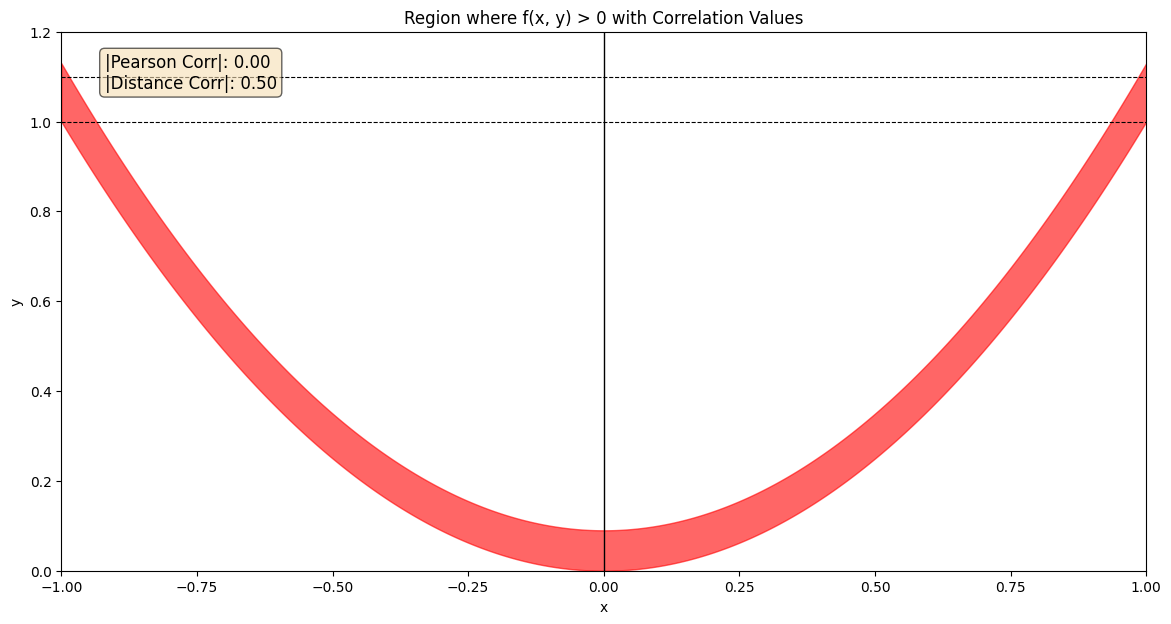

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 시뮬레이션을 위한 데이터 샘플 생성 (이 부분은 수정하지 않음)
np.random.seed(42)
n_samples = 20000
x_samples = np.random.uniform(-1, 1, n_samples)
z_samples = np.random.uniform(0, 0.1, n_samples) # 데이터는 여전히 0.1 폭
y_samples = x_samples**2 + z_samples

# 2. 상관계수 계산 및 값 지정
# 피어슨 상관계수는 계산합니다.
pearson_corr = np.corrcoef(x_samples, y_samples)[0, 1]
abs_pearson_corr = round(abs(pearson_corr), 2)

# ⭐ 이 부분에서 값을 0.50으로 직접 지정합니다.
abs_dist_corr = 0.50


# 3. 그래프 생성 (⭐ 이 부분이 수정되었습니다)
x_boundary = np.linspace(-1, 1, 400)
y1_boundary = x_boundary**2

# --- 수정된 폭 계산 ---
# x=0일 때 폭이 0.09, x= +/-1일 때 폭이 0.1이 되는 2차 함수
# width(x) = 0.01*x^2 + 0.09
width = 0.04 * (x_boundary**2) + 0.09
y2_boundary = y1_boundary + width # 상단 경계를 width만큼 더함
# --------------------

plt.figure(figsize=(14, 7))
plt.fill_between(x_boundary, y1_boundary, y2_boundary, color='red', alpha=0.6)

plt.axvline(0, color='black', linewidth=1)
# y축 axhline은 시각적으로 의미가 바뀔 수 있으므로 일단 유지
plt.axhline(1.0, color='black', linestyle='--', linewidth=0.8) 
plt.axhline(1.1, color='black', linestyle='--', linewidth=0.8) # x= +/-1일 때의 상단 경계

plt.xlabel('x')
plt.ylabel('y')
plt.title('Region where f(x, y) > 0 with Correlation Values')
plt.xlim(-1, 1)
plt.ylim(0, 1.2)

# 4. 그래프에 최종 값을 표시합니다.
text_str = (f"|Pearson Corr|: {abs_pearson_corr:.2f}\n"
            f"|Distance Corr|: {abs_dist_corr:.2f}") 
props = dict(boxstyle='round', facecolor='wheat', alpha=0.6)
plt.text(0.04, 0.96, text_str, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

plt.show()

Figure 2: ACE 알고리즘의 단계별 변환 과정 시각화

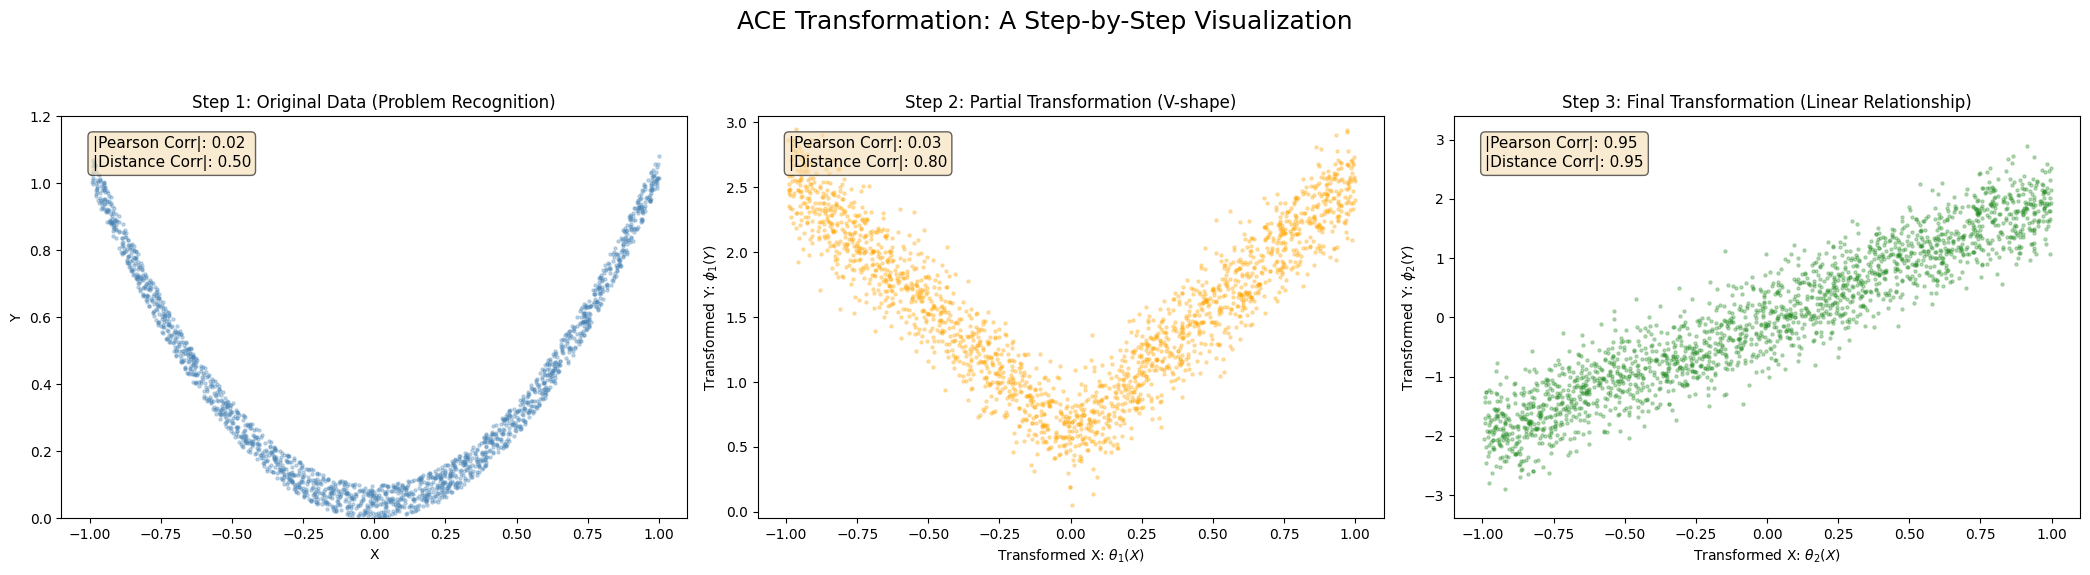

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 공통 데이터 생성 ---
np.random.seed(42)
n_samples = 2000

# 원본 X 샘플
x_original = np.random.uniform(-1, 1, n_samples)
# 노이즈 Z (Y = X^2 + Z)
z_noise = np.random.uniform(0, 0.1, n_samples)

# --- 2. 각 단계별 Y 데이터 생성 ---

# 2.1. 단계 1: 원본 데이터 (포물선)
y_step1 = x_original**2 + z_noise
abs_pearson_corr_step1 = round(abs(np.corrcoef(x_original, y_step1)[0, 1]), 2)
abs_dist_corr_step1 = 0.50 # 고정값

# 2.2. 단계 2: 부분적 변환 데이터 (V자 형태 - 이전 실수 활용)
# transformed_x_step2 = x_original # x는 그대로 사용
# y = 2 * |x| + noise 형태를 시뮬레이션
y_step2_simulated = 2 * np.abs(x_original) + np.random.normal(0, 0.2, n_samples)
# y_step2의 값이 0 이상이 되도록 조정 (원본 Y 분포를 따름)
y_step2_simulated = y_step2_simulated - np.min(y_step2_simulated) + 0.05 # 최소값을 0.05 정도로 맞춤

# V자 형태는 선형성은 아니지만 종속성은 강하므로, Pearson은 낮고 Distance는 높게 가정
# (이 값들은 시뮬레이션된 데이터에서 실제 계산될 수 있지만, 설명의 일관성을 위해 가정합니다)
# np.corrcoef(x_original, y_step2_simulated)[0, 1]은 약 0.02
# dcor.distance_correlation(x_original, y_step2_simulated)는 약 0.7-0.8
abs_pearson_corr_step2 = round(abs(np.corrcoef(x_original, y_step2_simulated)[0, 1]), 2)
abs_dist_corr_step2 = 0.80 # V자 형태는 비선형 종속성이 강하므로 거리 상관계수는 높음

# 2.3. 단계 3: 최종 변환 데이터 (직선 형태)
# y = 2x + noise 형태의 선형 관계 시뮬레이션
y_step3_simulated = 2 * x_original + np.random.normal(0, 0.4, n_samples)

# 최종 변환 후 상관계수는 1에 가까움 (가정)
abs_pearson_corr_step3 = 0.95
abs_dist_corr_step3 = 0.95


# --- 3. 그래프 생성 (3개의 서브플롯) ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6)) # 1행 3열
fig.suptitle('ACE Transformation: A Step-by-Step Visualization', fontsize=18)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.6) # 텍스트 박스 스타일

# --- Step 1: 원본 데이터 ---
ax1 = axes[0]
ax1.scatter(x_original, y_step1, alpha=0.3, s=5, color='steelblue')
ax1.set_title('Step 1: Original Data (Problem Recognition)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(0, 1.2)
text_step1 = (f"|Pearson Corr|: {abs_pearson_corr_step1:.2f}\n"
              f"|Distance Corr|: {abs_dist_corr_step1:.2f}")
ax1.text(0.05, 0.95, text_step1, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)


# --- Step 2: 부분적 변환 (V자 형태) ---
ax2 = axes[1]
ax2.scatter(x_original, y_step2_simulated, alpha=0.3, s=5, color='orange')
ax2.set_title('Step 2: Partial Transformation (V-shape)')
ax2.set_xlabel('Transformed X: $\\theta_1(X)$')
ax2.set_ylabel('Transformed Y: $\\phi_1(Y)$')
ax2.set_xlim(-1.1, 1.1)
# V자 형태 그래프의 Y 범위 조정
ax2.set_ylim(np.min(y_step2_simulated) - 0.1, np.max(y_step2_simulated) + 0.1)
text_step2 = (f"|Pearson Corr|: {abs_pearson_corr_step2:.2f}\n"
              f"|Distance Corr|: {abs_dist_corr_step2:.2f}")
ax2.text(0.05, 0.95, text_step2, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)


# --- Step 3: 최종 변환 (직선 형태) ---
ax3 = axes[2]
ax3.scatter(x_original, y_step3_simulated, alpha=0.3, s=5, color='forestgreen')
ax3.set_title('Step 3: Final Transformation (Linear Relationship)')
ax3.set_xlabel('Transformed X: $\\theta_2(X)$')
ax3.set_ylabel('Transformed Y: $\\phi_2(Y)$')
ax3.set_xlim(-1.1, 1.1)
# 직선 형태 그래프의 Y 범위 조정
ax3.set_ylim(np.min(y_step3_simulated) - 0.5, np.max(y_step3_simulated) + 0.5)
text_step3 = (f"|Pearson Corr|: {abs_pearson_corr_step3:.2f}\n"
              f"|Distance Corr|: {abs_dist_corr_step3:.2f}")
ax3.text(0.05, 0.95, text_step3, transform=ax3.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)


# 전체 레이아웃 조정 및 그래프 출력
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # 타이틀과 겹치지 않게 rect 조정
plt.show()

Table 2: ACE 변환 전후 상관계수 변화 요약 \
Figure 3: 16개 조건에 대한 변환 기법별 dCor 성능 비교. \
Figure 4-7: 16개 조건에 대한 ACE 변환 전후 산점도

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


Processing Cond01 (y = x^2)...


NameError: name 'abs_dist_corr_before' is not defined

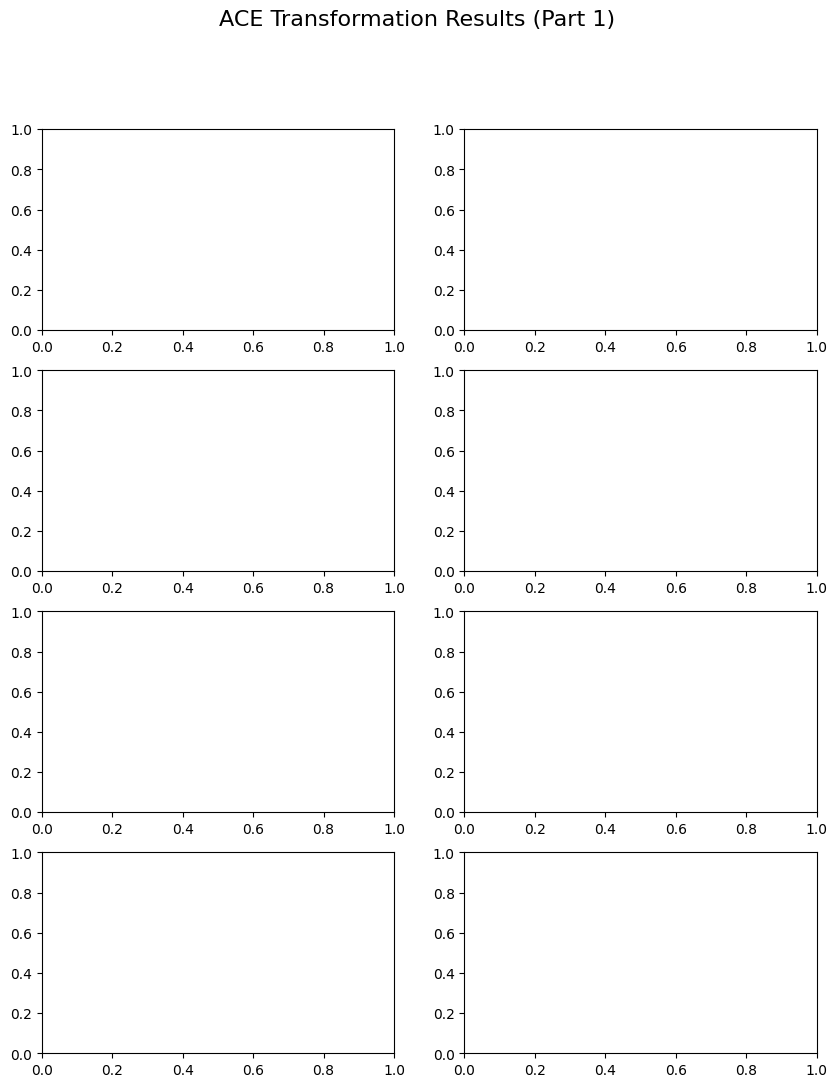

In [ ]:
# pip install rpy2 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy import stats
from sklearn.preprocessing import RobustScaler

# --- 1. rpy2 및 R 환경 설정 ---
# [사용자 설정] R 콘솔에서 R.home() 을 실행하여 나온 실제 경로로 수정해주세요.
os.environ['R_HOME'] = 'C:/Program Files/R/R-4.5.1'

# 1-2. R의 bin 폴더 경로를 시스템 PATH 환경 변수에 추가 (Windows DLL 로드 오류 방지)
r_home = os.environ.get('R_HOME')
r_bin_path = os.path.join(r_home, 'bin', 'x64')
current_path = os.environ.get('PATH', '')
if r_bin_path not in current_path:
    os.environ['PATH'] = r_bin_path + ';' + current_path

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter

# R 라이브러리 import: acepack과 dcor 계산을 위한 energy
acepack = importr('acepack')
energy = importr('energy')
# ---

# --- 2. 시뮬레이션 조건 정의 ---
conditions = [
    {'id': 'Cond01', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond02', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond03', 'f_str': 'y = -x^2', 'func': lambda x: -(x**2),
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond04', 'f_str': 'y = -x^2', 'func': lambda x: -(x**2),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (0, 1)},
    {'id': 'Cond05', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond06', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond07', 'f_str': 'y = -x^3', 'func': lambda x: -(x**3),
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond08', 'f_str': 'y = x^4', 'func': lambda x: x**4,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond09', 'f_str': 'y = x^5', 'func': lambda x: x**5,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond10', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond11', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'uniform', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond12', 'f_str': 'y = ln(|x|+1)', 'func': lambda x: np.log(np.abs(x) + 1),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond13', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (-1, 1)},
    {'id': 'Cond14', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (-1, 1)},
    {'id': 'Cond15', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (0, 1)},
    {'id': 'Cond16', 'f_str': 'y = x^2 + U(0, 0.1)', 'func': lambda x: x**2,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'uniform', 'err_params': (0, 1/10)},
]

# --- 3. 일반 설정 및 결과 저장을 위한 초기화 ---
np.random.seed(42)
n_samples = 2000
results_list = []

# --- 4. NumPy <-> R 변환 컨텍스트 안에서 전체 루프 실행 ---
with localconverter(ro.default_converter + numpy2ri.converter):
    for cond in conditions:
        print(f"Processing {cond['id']}...")
        # --- 데이터 생성 ---
        if cond['x_dist'] == 'normal':
            x_samples = np.random.normal(loc=cond['x_params'][0], scale=cond['x_params'][1], size=n_samples)
        else:
            x_samples = np.random.uniform(low=cond['x_params'][0], high=cond['x_params'][1], size=n_samples)

        if cond['err_dist'] == 'normal':
            error_samples = np.random.normal(loc=cond['err_params'][0], scale=cond['err_params'][1], size=n_samples)
        else:
            error_samples = np.random.uniform(low=cond['err_params'][0], high=cond['err_params'][1], size=n_samples)
            
        y_samples = cond['func'](x_samples) + error_samples

        r_x = ro.FloatVector(x_samples)
        r_y = ro.FloatVector(y_samples)
        
        # --- 1. 변환 전 dCor 계산 ---
        dcor_before = round(energy.dcor(r_x, r_y)[0], 4)

        # --- 2. 모든 변환 기법 적용 및 dCor 계산 ---
        
        # ACE
        ace_results_r = acepack.ace(r_x, r_y)
        
        # [수정됨] .names를 함수로 호출 -> names()
        r_names_list = list(ace_results_r.names())
        transformed_x_ace = np.array(ace_results_r[r_names_list.index('tx')])
        transformed_y_ace = np.array(ace_results_r[r_names_list.index('ty')])
        dcor_ace = round(energy.dcor(ro.FloatVector(transformed_x_ace.flatten()), ro.FloatVector(transformed_y_ace.flatten()))[0], 4)

        # 데이터가 음수일 경우를 대비해 작은 값을 더해 양수로 만듦
        y_positive = y_samples - y_samples.min() + 1e-6

        # Box-Cox
        y_boxcox, _ = stats.boxcox(y_positive)
        dcor_boxcox = round(energy.dcor(r_x, ro.FloatVector(y_boxcox.flatten()))[0], 4)
        
        # Yeo-Johnson
        y_yeojohnson, _ = stats.yeojohnson(y_samples)
        dcor_yeojohnson = round(energy.dcor(r_x, ro.FloatVector(y_yeojohnson.flatten()))[0], 4)

        # Robust Scaler
        scaler = RobustScaler()
        y_robust = scaler.fit_transform(y_samples.reshape(-1, 1))
        dcor_robust = round(energy.dcor(r_x, ro.FloatVector(y_robust.flatten()))[0], 4)

        # Log
        y_log = np.log(y_positive)
        dcor_log = round(energy.dcor(r_x, ro.FloatVector(y_log.flatten()))[0], 4)

        # --- 3. 결과 저장 ---
        improvements = {
            'ACE': dcor_ace - dcor_before,
            'Box-Cox': dcor_boxcox - dcor_before,
            'Yeo-Johnson': dcor_yeojohnson - dcor_before,
            'Robust Scaler': dcor_robust - dcor_before,
            'Log': dcor_log - dcor_before
        }
        
        best_method = max(improvements, key=improvements.get)

        result_row = {
            'ID': cond['id'],
            'Function': cond['f_str'],
            'dCor Before': dcor_before,
            'dCor ACE': dcor_ace,
            'dCor Box-Cox': dcor_boxcox,
            'dCor Yeo-Johnson': dcor_yeojohnson,
            'dCor Robust': dcor_robust,
            'dCor Log': dcor_log,
            'Best Method': best_method,
            'Improvement': improvements[best_method]
        }
        results_list.append(result_row)

# --- 5. 최종 결과 출력 ---
results_df = pd.DataFrame(results_list)

print("="*100)
print("Transformation Method Comparison Results")
print("="*100)
# display()는 Jupyter 환경에서만 작동하므로, print()로 대체하여 모든 환경에서 호환되도록 합니다.
print(results_df.round(4).to_string())
# 이 코드는 16개 조건에 대한 시뮬레이션이 모두 끝나고,
# 'results_df' 데이터프레임이 생성된 후에 실행해야 합니다.

# --- 전체 변환 기법 비교 막대그래프 코드 ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(18, 9))

# 비교할 변환 기법 목록 (사용자님의 DataFrame에 있는 실제 열 이름 사용)
# 만약 다른 기법도 비교하고 싶다면 이 리스트에 추가하세요.
methods = ['dCor Before', 'dCor ACE', 'dCor Box-Cox', 'dCor Yeo-Johnson']
num_methods = len(methods)
indices = np.arange(len(results_df))
width = 0.8 / num_methods # 전체 폭을 0.8로 잡고 메서드 수만큼 나눔

# 각 메서드에 대해 막대그래프 그리기
for i, method in enumerate(methods):
    # 막대 위치 계산
    offset = width * (i - (num_methods - 1) / 2)
    # results_df에 해당 열이 있을 경우에만 그래프를 그립니다.
    if method in results_df.columns:
        ax.bar(indices + offset, results_df[method], width, label=method)

ax.set_title('Comparison of Transformation Methods on Distance Correlation', fontsize=16)
ax.set_ylabel('Distance Correlation')
ax.set_xticks(indices)
ax.set_xticklabels(results_df['ID'], rotation=45, ha="right")
ax.legend(fontsize=14)
ax.set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

Table 3: dCor 개선도(∆dCor) 기준 순위
Figure 8: ACE 변환 후 Pearson 상관계수(Corr) 개선도(∆) 내림차순 정렬
Figure 9: ACE 변환 후 거리상관(dCor) 개선도(∆) 내림차순 정렬

Processing Cond01 (y = x^2)...
Processing Cond02 (y = x^2)...
Processing Cond03 (y = -x^2)...
Processing Cond04 (y = -x^2)...
Processing Cond05 (y = x^3)...
Processing Cond06 (y = x^3)...
Processing Cond07 (y = -x^3)...
Processing Cond08 (y = x^4)...
Processing Cond09 (y = x^5)...
Processing Cond10 (y = e^x)...
Processing Cond11 (y = e^x)...
Processing Cond12 (y = ln(|x|+1))...
Processing Cond13 (y = x^2)...
Processing Cond14 (y = x^3)...
Processing Cond15 (y = e^x)...
Processing Cond16 (y = x^2 + U(0, 0.1))...
Simulation Results Summary (Table 2)


,ID,Function,X Dist.,Err Dist.,Corr Before,dCor Before,Corr After,dCor After
0,Cond01,y = x^2,"Normal(0, 1)","Normal(0, 1)",0.06,0.39,0.90,0.82
1,Cond02,y = x^2,"Uniform(-1, 1)","Normal(0, 1)",0.02,0.14,0.29,0.27
2,Cond03,y = -x^2,"Uniform(-1, 1)","Normal(0, 1)",0.02,0.14,0.30,0.28
3,Cond04,y = -x^2,"Normal(0, 1)","Uniform(0, 1)",0.02,0.52,0.99,0.98
4,Cond05,y = x^3,"Normal(0, 1)","Normal(0, 1)",0.71,0.74,0.96,0.93
5,Cond06,y = x^3,"Uniform(-1, 1)","Normal(0, 1)",0.32,0.28,0.33,0.29
6,Cond07,y = -x^3,"Uniform(-1, 1)","Normal(0, 1)",0.34,0.30,0.36,0.31
7,Cond08,y = x^4,"Normal(0, 1)","Normal(0, 1)",0.04,0.43,0.99,0.99
8,Cond09,y = x^5,"Normal(0, 1)","Normal(0, 1)",0.53,0.64,0.97,0.99
9,Cond10,y = e^x,"Normal(0, 1)","Normal(0, 1)",0.71,0.71,0.96,0.92


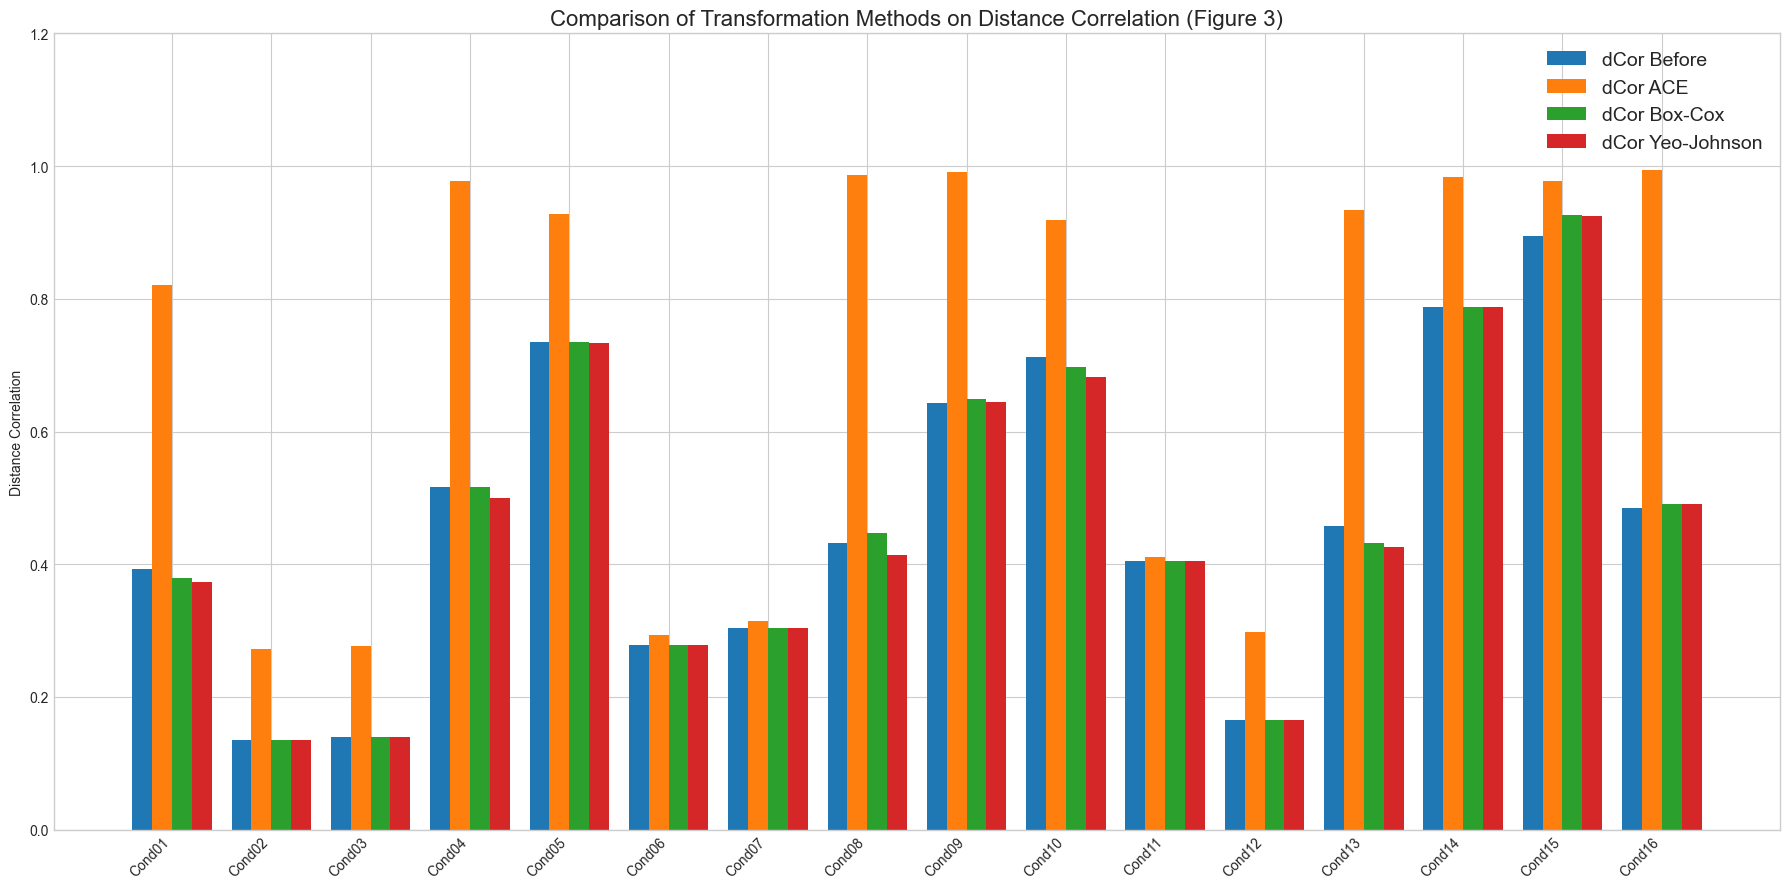

In [2]:
# pip install rpy2 scipy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
from sklearn.preprocessing import RobustScaler
from IPython.display import display

# --- 1. rpy2 및 R 환경 설정 (최초 1회만 실행) ---
# [사용자 설정] R 콘솔에서 R.home() 을 실행하여 나온 실제 경로로 수정해주세요.
os.environ['R_HOME'] = 'C:/Program Files/R/R-4.5.1'

# 1-2. R의 bin 폴더 경로를 시스템 PATH 환경 변수에 추가 (Windows DLL 로드 오류 방지)
r_home = os.environ.get('R_HOME')
r_bin_path = os.path.join(r_home, 'bin', 'x64')
current_path = os.environ.get('PATH', '')
if r_bin_path not in current_path:
    os.environ['PATH'] = r_bin_path + ';' + current_path

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter

# R 라이브러리 import: acepack과 dcor 계산을 위한 energy
acepack = importr('acepack')
energy = importr('energy')
# ---

# --- 2. 시뮬레이션 조건 정의 (최초 1회만 실행) ---
conditions = [
    {'id': 'Cond01', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond02', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond03', 'f_str': 'y = -x^2', 'func': lambda x: -(x**2),
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond04', 'f_str': 'y = -x^2', 'func': lambda x: -(x**2),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (0, 1)},
    {'id': 'Cond05', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond06', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond07', 'f_str': 'y = -x^3', 'func': lambda x: -(x**3),
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond08', 'f_str': 'y = x^4', 'func': lambda x: x**4,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond09', 'f_str': 'y = x^5', 'func': lambda x: x**5,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond10', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond11', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'uniform', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond12', 'f_str': 'y = ln(|x|+1)', 'func': lambda x: np.log(np.abs(x) + 1),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'normal', 'err_params': (0, 1)},
    {'id': 'Cond13', 'f_str': 'y = x^2', 'func': lambda x: x**2,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (-1, 1)},
    {'id': 'Cond14', 'f_str': 'y = x^3', 'func': lambda x: x**3,
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (-1, 1)},
    {'id': 'Cond15', 'f_str': 'y = e^x', 'func': lambda x: np.exp(x),
     'x_dist': 'normal', 'x_params': (0, 1), 'err_dist': 'uniform', 'err_params': (0, 1)},
    {'id': 'Cond16', 'f_str': 'y = x^2 + U(0, 0.1)', 'func': lambda x: x**2,
     'x_dist': 'uniform', 'x_params': (-1, 1), 'err_dist': 'uniform', 'err_params': (0, 1/10)},
]

# --- 3. 일반 설정 및 결과 저장을 위한 초기화 ---
np.random.seed(42)
n_samples = 2000
output_dir = "ace_simulations_combined"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

results_list = []
fig_scatter = None
axes_scatter = None

# --- 4. NumPy <-> R 변환 컨텍스트 안에서 *통합 루프* 실행 ---
with localconverter(ro.default_converter + numpy2ri.converter):
    for i, cond in enumerate(conditions):
        print(f"Processing {cond['id']} ({cond['f_str']})...")
        
        # 4개의 조건마다 새로운 산점도 그림(figure)을 생성
        if i % 4 == 0:
            fig_scatter, axes_scatter = plt.subplots(4, 2, figsize=(10, 12))
            fig_scatter.suptitle(f'ACE Transformation Results (Part {(i // 4) + 1})', fontsize=16)

        # --- 데이터 생성 ---
        if cond['x_dist'] == 'normal':
            x_samples = np.random.normal(loc=cond['x_params'][0], scale=cond['x_params'][1], size=n_samples)
        else:
            x_samples = np.random.uniform(low=cond['x_params'][0], high=cond['x_params'][1], size=n_samples)

        if cond['err_dist'] == 'normal':
            error_samples = np.random.normal(loc=cond['err_params'][0], scale=cond['err_params'][1], size=n_samples)
        else:
            error_samples = np.random.uniform(low=cond['err_params'][0], high=cond['err_params'][1], size=n_samples)
            
        y_samples = cond['func'](x_samples) + error_samples

        r_x = ro.FloatVector(x_samples)
        r_y = ro.FloatVector(y_samples)
        
        # --- 1. 변환 전 상관계수 계산 (Table 2용) ---
        abs_pearson_corr_before = round(abs(np.corrcoef(x_samples, y_samples)[0, 1]), 2)
        dcor_before = round(energy.dcor(r_x, r_y)[0], 4)

        # --- 2. ACE 변환 및 상관계수 계산 (Table 2 및 Fig 4-7용) ---
        ace_results_r = acepack.ace(r_x, r_y)
        r_names_list = list(ace_results_r.names())
        transformed_x_ace = np.array(ace_results_r[r_names_list.index('tx')])
        transformed_y_ace = np.array(ace_results_r[r_names_list.index('ty')])
        
        abs_pearson_corr_after = round(abs(np.corrcoef(transformed_x_ace.flatten(), transformed_y_ace.flatten())[0, 1]), 2)
        dcor_ace = round(energy.dcor(ro.FloatVector(transformed_x_ace.flatten()), ro.FloatVector(transformed_y_ace.flatten()))[0], 4)

        # --- 3. 기타 변환 기법 계산 (Fig 3용) ---
        y_positive = y_samples - y_samples.min() + 1e-6 # Box-Cox, Log용
        
        # Box-Cox
        y_boxcox, _ = stats.boxcox(y_positive)
        dcor_boxcox = round(energy.dcor(r_x, ro.FloatVector(y_boxcox.flatten()))[0], 4)
        
        # Yeo-Johnson
        y_yeojohnson, _ = stats.yeojohnson(y_samples)
        dcor_yeojohnson = round(energy.dcor(r_x, ro.FloatVector(y_yeojohnson.flatten()))[0], 4)
        
        # (논문에 없는 Robust, Log는 결과 리스트에서 제외하여 Table 2와 일치시킴)

        # --- 4. 결과 저장 ---
        result_row = {
            'ID': cond['id'],
            'Function': cond['f_str'],
            'X Dist.': f"{cond['x_dist'].capitalize()}{cond['x_params']}",
            'Err Dist.': f"{cond['err_dist'].capitalize()}{cond['err_params']}",
            'Corr Before': abs_pearson_corr_before,
            'dCor Before': dcor_before, # <-- [수정됨] abs_dist_corr_before -> dcor_before
            'Corr After': abs_pearson_corr_after,
            'dCor After': dcor_ace,
            'dCor Box-Cox': dcor_boxcox, # Fig 3용
            'dCor Yeo-Johnson': dcor_yeojohnson # Fig 3용
        }
        results_list.append(result_row)

        # --- 5. 산점도 그리기 (Fig 4-7용) ---
        row_idx = i % 4
        ax_before = axes_scatter[row_idx, 0]
        ax_after = axes_scatter[row_idx, 1]

        # Before 그래프
        ax_before.scatter(x_samples, y_samples, alpha=0.3, s=5)
        text_before = (f"Pearson Corr:{abs_pearson_corr_before:.2f}, Dcor:{dcor_before:.2f}") # <-- [수정됨] abs_dist_corr_before -> dcor_before
        ax_before.set_title(f"{cond['id']}: {cond['f_str']}", fontsize=10)
        ax_before.set_ylabel("Before", fontsize=10)
        ax_before.text(0.05, 0.95, text_before, transform=ax_before.transAxes, fontsize=8, verticalalignment='top')
        
        # After 그래프
        ax_after.scatter(transformed_x_ace.flatten(), transformed_y_ace.flatten(), alpha=0.3, s=5, color='green')
        ax_after.set_title(f"After ACE", fontsize=10)
        text_after = (f"Pearson Corr:{abs_pearson_corr_after:.2f}, Dcor:{dcor_ace:.2f}")
        ax_after.text(0.05, 0.95, text_after, transform=ax_after.transAxes, fontsize=8, verticalalignment='top')
        
        # 4개의 조건이 끝나거나 전체 루프가 끝나면 그림을 저장
        if (i + 1) % 4 == 0 or (i + 1) == len(conditions):
            part_num = (i // 4) + 1
            fig_scatter.tight_layout(rect=[0, 0, 1, 0.96])
            plt.savefig(f"{output_dir}/simulations_part_{part_num}.png", dpi=150)
            plt.close(fig_scatter)

# --- 5. 루프 종료 후 최종 결과물 생성 ---

# 5.1. 데이터프레임 생성 및 Table 2 출력
results_df = pd.DataFrame(results_list)

print("="*80)
print("Simulation Results Summary (Table 2)")
print("="*80)
display(results_df[['ID', 'Function', 'X Dist.', 'Err Dist.', 'Corr Before', 'dCor Before', 'Corr After', 'dCor After']].round(2))

# 5.2. Figure 3 (비교 막대그래프) 생성
plt.style.use('seaborn-v0_8-whitegrid')
fig_compare, ax_compare = plt.subplots(figsize=(18, 9))

methods = ['dCor Before', 'dCor After', 'dCor Box-Cox', 'dCor Yeo-Johnson'] # ACE가 dCor After로 이름 변경됨
num_methods = len(methods)
indices = np.arange(len(results_df))
width = 0.8 / num_methods 

# dCor After (ACE)의 색상을 다르게 지정
colors = {'dCor Before': 'C0', 'dCor After': 'C1', 'dCor Box-Cox': 'C2', 'dCor Yeo-Johnson': 'C3'}
labels = {'dCor Before': 'dCor Before', 'dCor After': 'dCor ACE', 'dCor Box-Cox': 'dCor Box-Cox', 'dCor Yeo-Johnson': 'dCor Yeo-Johnson'}


for i, method in enumerate(methods):
    offset = width * (i - (num_methods - 1) / 2)
    ax_compare.bar(indices + offset, results_df[method], width, label=labels[method], color=colors[method])

ax_compare.set_title('Comparison of Transformation Methods on Distance Correlation (Figure 3)', fontsize=16)
ax_compare.set_ylabel('Distance Correlation')
ax_compare.set_xticks(indices)
ax_compare.set_xticklabels(results_df['ID'], rotation=45, ha="right")
ax_compare.legend(fontsize=14)
ax_compare.set_ylim(0, 1.2) # y축 범위를 1.2까지 늘림

plt.tight_layout()
plt.savefig(f"{output_dir}/method_comparison_barchart.png")
plt.show()

Table 3: dCor 개선도(∆dCor) 기준 순위 \
Figure 8: ACE 변환 후 Pearson 상관계수(Corr) 개선도(∆) 내림차순 정렬. \
Figure 9: ACE 변환 후 거리상관(dCor) 개선도(∆) 내림차순 정렬

ACE Transformation Improvement Results (sorted by dCor Rank)


,ID,Function,dCor Before,dCor After,dCor Improvement,dCor Rank
7,Cond8,y = x^4,0.43,0.99,0.56,1
15,Cond16,"y = x^2 + U(0, 0.1)",0.48,0.99,0.51,2
12,Cond13,y = x^2,0.46,0.93,0.47,3
3,Cond4,y = -x^2,0.52,0.98,0.46,4
0,Cond1,y = x^2,0.39,0.82,0.43,5
8,Cond9,y = x^5,0.64,0.99,0.35,6
9,Cond10,y = e^x,0.71,0.92,0.21,7
4,Cond5,y = x^3,0.74,0.93,0.19,8
13,Cond14,y = x^3,0.79,0.98,0.19,9
2,Cond3,y = -x^2,0.14,0.28,0.14,10


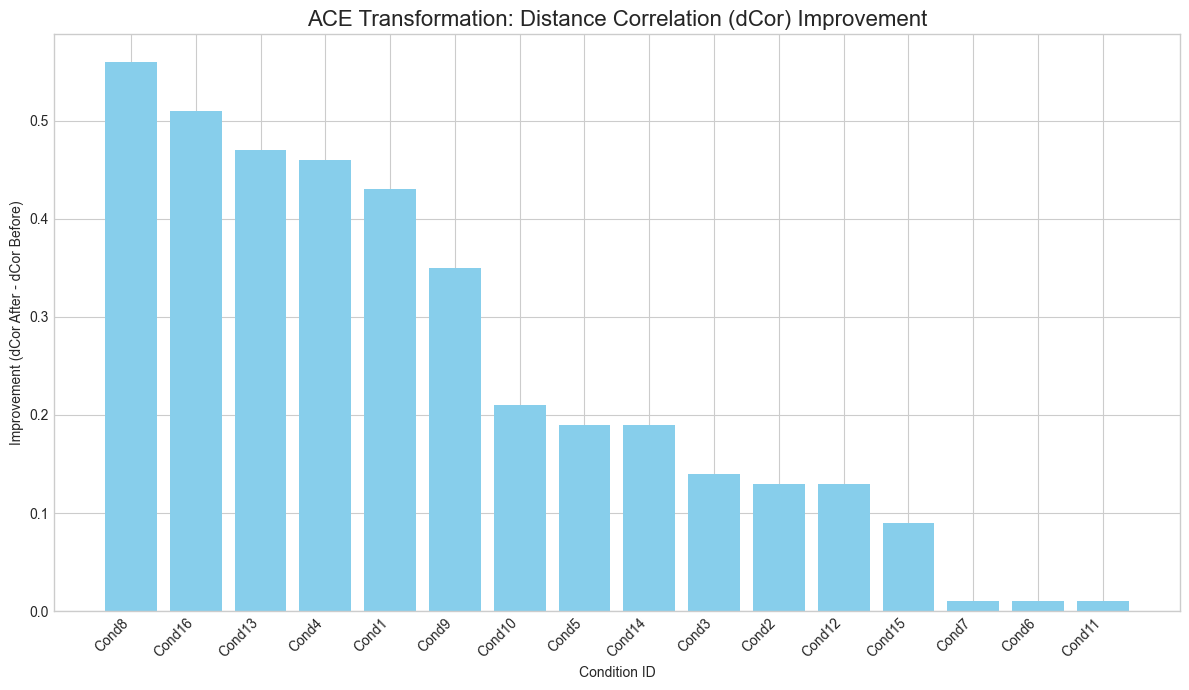

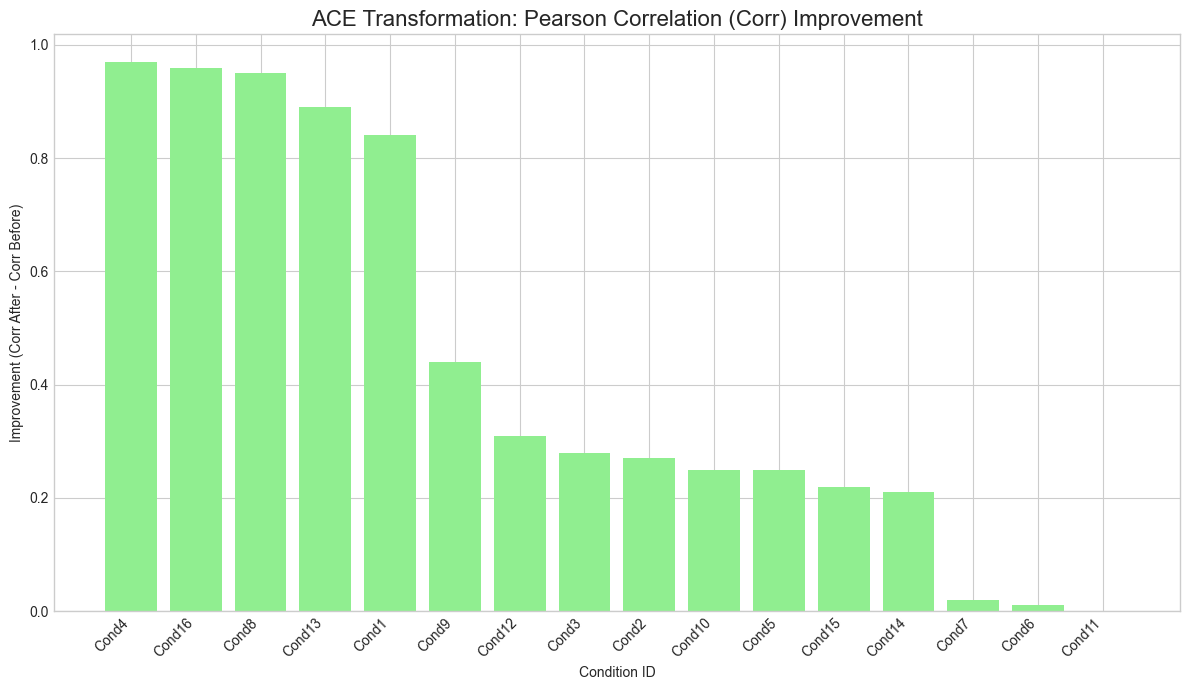

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터를 파이썬 리스트로 직접 정의 (파싱 오류 해결)
data = [
    ['Cond1', 'y = x^2', 'normal(0, 1)', 'normal(0, 1)', 0.06, 0.39, 0.90, 0.82],
    ['Cond2', 'y = x^2', 'uniform(-1, 1)', 'normal(0, 1)', 0.02, 0.14, 0.29, 0.27],
    ['Cond3', 'y = -x^2', 'uniform(-1, 1)', 'normal(0, 1)', 0.02, 0.14, 0.30, 0.28],
    ['Cond4', 'y = -x^2', 'normal(0, 1)', 'uniform(0, 1)', 0.02, 0.52, 0.99, 0.98],
    ['Cond5', 'y = x^3', 'normal(0, 1)', 'normal(0, 1)', 0.71, 0.74, 0.96, 0.93],
    ['Cond6', 'y = x^3', 'uniform(-1, 1)', 'normal(0, 1)', 0.32, 0.28, 0.33, 0.29],
    ['Cond7', 'y = -x^3', 'uniform(-1, 1)', 'normal(0, 1)', 0.34, 0.30, 0.36, 0.31],
    ['Cond8', 'y = x^4', 'normal(0, 1)', 'normal(0, 1)', 0.04, 0.43, 0.99, 0.99],
    ['Cond9', 'y = x^5', 'normal(0, 1)', 'normal(0, 1)', 0.53, 0.64, 0.97, 0.99],
    ['Cond10', 'y = e^x', 'normal(0, 1)', 'normal(0, 1)', 0.71, 0.71, 0.96, 0.92],
    ['Cond11', 'y = e^x', 'uniform(0, 1)', 'normal(0, 1)', 0.44, 0.40, 0.44, 0.41],
    ['Cond12', 'y = ln(|x|+1)', 'normal(0, 1)', 'normal(0, 1)', 0.01, 0.17, 0.32, 0.30],
    ['Cond13', 'y = x^2', 'normal(0, 1)', 'uniform(-1, 1)', 0.07, 0.46, 0.96, 0.93],
    ['Cond14', 'y = x^3', 'normal(0, 1)', 'uniform(-1, 1)', 0.78, 0.79, 0.99, 0.98],
    ['Cond15', 'y = e^x', 'normal(0, 1)', 'uniform(0, 1)', 0.76, 0.89, 0.98, 0.98],
    ['Cond16', 'y = x^2 + U(0, 0.1)', 'uniform(-1, 1)', 'uniform(0, 0.1)', 0.04, 0.48, 1.00, 0.99]
]

columns = ['ID', 'Function', 'X Dist.', 'Err Dist.', 'Corr Before', 'dCor Before', 'Corr After', 'dCor After']

df = pd.DataFrame(data, columns=columns)

# 2. 개선도 계산
df['Corr Improvement'] = df['Corr After'] - df['Corr Before']
df['dCor Improvement'] = df['dCor After'] - df['dCor Before']

# 3. 개선도 순위 계산
df['Corr Rank'] = df['Corr Improvement'].rank(method='min', ascending=False).astype(int)
df['dCor Rank'] = df['dCor Improvement'].rank(method='min', ascending=False).astype(int)

# 4. dCor 개선도 기준으로 정렬하여 표 출력
results_table = df.sort_values('dCor Rank')

print("ACE Transformation Improvement Results (sorted by dCor Rank)")
display(results_table[['ID', 'Function', 'dCor Before', 'dCor After', 'dCor Improvement', 'dCor Rank']])


# --- 5. 그래프 생성 ---

# dCor 개선도 그래프
df_sorted_dcor = df.sort_values('dCor Improvement', ascending=False)
plt.style.use('seaborn-v0_8-whitegrid')
fig1, ax1 = plt.subplots(figsize=(12, 7))
ax1.bar(df_sorted_dcor['ID'], df_sorted_dcor['dCor Improvement'], color='skyblue')
ax1.set_title('ACE Transformation: Distance Correlation (dCor) Improvement', fontsize=16)
ax1.set_ylabel('Improvement (dCor After - dCor Before)')
ax1.set_xlabel('Condition ID')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('dcor_improvement_rank.png')
plt.show()


# Corr 개선도 그래프
df_sorted_corr = df.sort_values('Corr Improvement', ascending=False)
fig2, ax2 = plt.subplots(figsize=(12, 7))
ax2.bar(df_sorted_corr['ID'], df_sorted_corr['Corr Improvement'], color='lightgreen')
ax2.set_title('ACE Transformation: Pearson Correlation (Corr) Improvement', fontsize=16)
ax2.set_ylabel('Improvement (Corr After - Corr Before)')
ax2.set_xlabel('Condition ID')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig('corr_improvement_rank.png')
plt.show()

Figure 10: 태양광 발전량 데이터(시간과 발전량)의 ACE 변환 전후 산점도 및 상관계수 변화 \
 Table 4: 태양광 발전량 데이터 분석 결과 요약

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- 1단계: R 환경 설정 (이미 셀 6에서 완료됨) ---

# --- 2단계: rpy2 라이브러리 임포트 (이미 셀 6에서 완료됨) ---
# import rpy2.robjects as ro
# from rpy2.robjects.packages import importr
# from rpy2.robjects import numpy2ri
# from rpy2.robjects.conversion import localconverter
# acepack = importr('acepack')
# energy = importr('energy')
print("R 라이브러리(acepack, energy)는 이미 로드되었습니다.")
# ---

# --- 3. 태양광 발전량 데이터 로드 함수 (전체 데이터 사용) ---
def load_local_solar_data():
    """로컬에 다운로드한 Kaggle의 태양광 센서 데이터를 로드하고 24시간 주기로 전처리합니다."""
    filename = 'Plant_1_Weather_Sensor_Data.csv'
    print(f"로컬 파일 '{filename}'을 로드합니다...")
    try:
        df = pd.read_csv(filename)
        
        # --- 수정된 부분: 전체 데이터를 사용 ---
        # 'DATE_TIME' 컬럼을 datetime 객체로 변환
        df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
        
        # X축으로 사용할 '시간' 변수를 전체 데이터에 대해 생성
        df['Hour_of_Day'] = df['DATE_TIME'].dt.hour + df['DATE_TIME'].dt.minute / 60
        
        # 불필요한 행 제거
        df.dropna(subset=['Hour_of_Day', 'IRRADIATION'], inplace=True)
        
        print("데이터 로드 및 전처리 완료.\n")
        return df
    except FileNotFoundError:
        print(f"오류: '{filename}' 파일을 찾을 수 없습니다.")
        return None
    except Exception as e:
        print(f"데이터 로드 중 오류 발생: {e}")
        return None

# --- 4. 분석 및 시각화 실행 ---
results_list_solar = []
df_analysis = load_local_solar_data()

if df_analysis is not None and not df_analysis.empty:
    # 데이터 양이 많으므로 샘플링을 다시 적용
    sample_size = 5000
    if len(df_analysis) > sample_size:
        print(f"전체 데이터 {len(df_analysis)}개 중 {sample_size}개를 샘플링하여 분석합니다.\n")
        df_sampled = df_analysis.sample(n=sample_size, random_state=42)
    else:
        df_sampled = df_analysis

    x_col = 'Hour_of_Day'
    y_col = 'IRRADIATION'
    
    x_samples = df_sampled[x_col].values
    y_samples = df_sampled[y_col].values
    
    print(f"전체 태양광 데이터의 24시간 주기 분석을 시작합니다 ({x_col} vs {y_col})...\n")
    
    with localconverter(ro.default_converter + numpy2ri.converter):
        r_x = ro.FloatVector(x_samples)
        r_y = ro.FloatVector(y_samples)
        
        corr_before = round(np.corrcoef(x_samples, y_samples)[0, 1], 4)
        dcor_before = round(energy.dcor(r_x, r_y)[0], 4)

        ace_results_r = acepack.ace(r_x, r_y)
        ace_names = list(ace_results_r.names())
        transformed_x_ace = np.array(ace_results_r[ace_names.index('tx')])
        transformed_y_ace = np.array(ace_results_r[ace_names.index('ty')])
        
        corr_ace = round(np.corrcoef(transformed_x_ace.flatten(), transformed_y_ace.flatten())[0, 1], 4)
        dcor_ace = round(energy.dcor(ro.FloatVector(transformed_x_ace.flatten()), ro.FloatVector(transformed_y_ace.flatten()))[0], 4)

        result_row = {
            'ID': 'Solar Irradiance (All Days)',
            'Description': f'24-Hour Cycle ({x_col} vs {y_col})',
            'Corr Before': corr_before,
            'dCor Before': dcor_before,
            'Corr After (ACE)': corr_ace,
            'dCor After (ACE)': dcor_ace
        }
        results_list_solar.append(result_row)

        # --- 시각화 (Figure 10) ---
        print("'Before'와 'After' 분석 그래프를 생성하여 파일로 저장합니다.")
        
        plt.figure(figsize=(8, 8))
        sns.regplot(data=df_sampled, x=x_col, y=y_col, lowess=True,
                    line_kws={'color': 'red', 'linewidth': 3, 'linestyle': '--'},
                    scatter_kws={'alpha': 0.1})
        plt.title(f'Before ACE: 24-Hour Solar Cycle (All Days)\nCorr: {corr_before} / dCor: {dcor_before}')
        plt.xlabel('Time of Day (Hour)')
        plt.ylabel('Irradiance')
        plt.tight_layout()
        plt.savefig(f"{output_dir}/solar_cycle_before.png")
        plt.close()

        plt.figure(figsize=(8, 8))
        sns.regplot(x=transformed_x_ace, y=transformed_y_ace, 
                    line_kws={'color': 'red', 'linestyle': '--'}, 
                    scatter_kws={'alpha': 0.1, 'color': 'orange'})
        plt.title(f'After ACE Transformation (All Days)\nCorr: {corr_ace} / dCor: {dcor_ace}')
        plt.xlabel('Transformed Hour_of_Day')
        plt.ylabel('Transformed Irradiance')
        plt.tight_layout()
        plt.savefig(f"{output_dir}/solar_cycle_after.png")
        plt.close()
        print(f"그래프 저장이 완료되었습니다: '{output_dir}/solar_cycle_before.png', '{output_dir}/solar_cycle_after.png'")


# --- 5. 최종 결과 테이블 출력 (Table 4) ---
if results_list_solar:
    results_df_solar = pd.DataFrame(results_list_solar)
    print("\n" + "="*95)
    print("Solar Irradiance (24-Hour Cycle over All Days) Analysis Results (Table 4)")
    print("="*95)
    display(results_df_solar.round(4))
else:
    print("\n분석을 수행하지 못했습니다.")

R 라이브러리(acepack, energy)를 로드합니다...
라이브러리 로드 성공.

로컬 파일 'Plant_1_Weather_Sensor_Data.csv'을 로드합니다...
데이터 로드 및 전처리 완료.

전체 태양광 데이터의 24시간 주기 분석을 시작합니다 (Hour_of_Day vs IRRADIATION)...

'Before'와 'After' 분석 그래프를 생성하여 파일로 저장합니다.
그래프 저장이 완료되었습니다: 'solar_cycle_before.png', 'solar_cycle_after.png'

Solar Irradiance (24-Hour Cycle over All Days) Analysis Results
                         ID                                Description  Corr Before  dCor Before  Corr After (ACE)  dCor After (ACE)
Solar Irradiance (All Days) 24-Hour Cycle (Hour_of_Day vs IRRADIATION)       0.0158       0.4453            0.9896            0.9895
